# Fitting IBM Device Data by Cosmo Wu

## The problem

The main use of Bayesian statistics is to find unknown variables and fit curves. In this notebook, we use such techniques to fit real-world data from an IBM Quantum Device.

## My solution

For this notebook, I went with a rather straightforward solution by following the steps of the previous DiRP notebooks and using the integration method for Bayesian inference.

Previously, we established that in the non-ideal case for a quantum device, the probability should be approximated as
$$ p = \cos^2\!\left(\frac{\omega t}{2} + B\right) $$
and not as
$$ p = \cos^2\!\left(\frac{\omega t}{2}\right) $$
due to potential disturbances.

Previously, we computed $\omega$ as the expected value from a single-variable posterior. This time, we must estimate two variables, meaning we compute both
$$ \omega_{\text{final}} = \iint \omega \; \mathcal{L}(\omega, B \mid D) \; d\omega \; dB $$
and
$$ B_{\text{final}} = \iint B \; \mathcal{L}(\omega, B \mid D) \; d\omega \; dB $$

This can be done in the following steps:

1. We define a grid of candidate values for $\omega$ and $B$ over their respective domains.
2. For every combination $(\omega, B)$ on this grid, we compute the log-likelihood given the observed data $D$.
3. We convert the log-likelihoods into normalized posterior weights using the log-sum-exp trick for numerical stability.
4. We compute the posterior mean of each parameter as a weighted average over the grid, yielding $\omega_{\text{final}}$ and $B_{\text{final}}$.
5. Using these estimates, we evaluate $p = \cos^2\!\left(\frac{\omega_{\text{final}}\, t}{2} + B_{\text{final}}\right)$ and plot the resulting curve against the measured data.

## Potential Limits

At the bottom of my code, there is a somewhat accurate graph. However, there is a limit due to memory, as the notebook cannot make too large of a grid for the integration method, leading to some precision lost.

## Importing Necessaary Functions

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import pickle
from scipy.special import logsumexp

## Opening Data Files

In [2]:
with open('IBM_dirp_raw.data', 'rb') as filehandle:
    xs2, ys2 = pickle.load(filehandle)

In [3]:
ts2 = xs2
Ds2 = ys2

In [4]:
len(ts2)

400

In [6]:
with open('IBM_dirp.data', 'rb') as filehandle:
    xs, ys = pickle.load(filehandle)

ts = xs
Ds = ys

## Neccessary Functions

In [20]:
from scipy.special import logsumexp

def plot_data(ts, Ds, ref = None):
    fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
    ax.set_title("Precession")
    if ref is not None:
      ax.plot(ts, ref, color="black", linestyle="--")
    else:
      ax.plot(ts, Ds, color="black", linestyle="--")

    ax.scatter(ts, Ds, marker="x",s=50, zorder = 2, linewidth=3.5, color="firebrick")

    ax.minorticks_on()
    ax.grid(which="major", linestyle="-", alpha=0.6)
    ax.grid(which="minor", linestyle=":", alpha=0.4)

    ax.set_xlabel("Time (t)")
    ax.set_ylabel("Fraction of + outcomes")

    plt.show()

def plot_likelihood(ps, Ls, log):
    fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

    ax.set_title("Log-likelihood" if log else "Likelihood")
    ax.plot(ps, Ls, color="black")

    ax.minorticks_on()
    ax.grid(which="major", linestyle="-", alpha=0.6)
    ax.grid(which="minor", linestyle=":", alpha=0.4)

    ax.set_xlabel("Value of $p_1$")
    ax.set_ylabel("Likelihood")

    plt.show()

def prob2(ts, w, B):
  return np.cos(w*ts/2 + B)**2

def likelihood_2d(ws, Bs, ts, ys, eps=1e-10):
    # ws: shape (Nw,), Bs: shape (NB,)
    # Build 3D arrays: (Nw, NB, Nt)
    w_grid = ws[:, None, None]
    B_grid = Bs[None, :, None]
    t_grid = ts[None, None, :]

    p1s = np.cos(w_grid * t_grid / 2.0 + B_grid) ** 2
    p1s = np.clip(p1s, eps, 1 - eps)

    # ys has shape (Nt,), broadcast and sum over time axis
    Ls = np.sum(ys * np.log(p1s) + (1 - ys) * np.log1p(-p1s), axis=2)
    return Ls  # shape (Nw, NB)

def bayesian_estimate(xs, ys, w_domain, B_domain, Npoints = int(200), log = True, std = False):
    ws = np.linspace(w_domain[0],w_domain[1], Npoints)
    Bs = np.linspace(B_domain[0],B_domain[1], Npoints)
    Ls = likelihood_2d(ws, Bs, xs, ys)
    w_grid, B_grid = np.meshgrid(ws, Bs, indexing='ij')
    flat_Ls = Ls.ravel()
    flat_ws = w_grid.ravel()
    flat_Bs = B_grid.ravel()

    if log:
        logZ = logsumexp(flat_Ls)
        weights = np.exp(flat_Ls - logZ)
    else:
        weights = flat_Ls / np.sum(flat_Ls)

    w_est = np.sum(weights * flat_ws)
    B_est = np.sum(weights * flat_Bs)
    return w_est, B_est

## Main Code

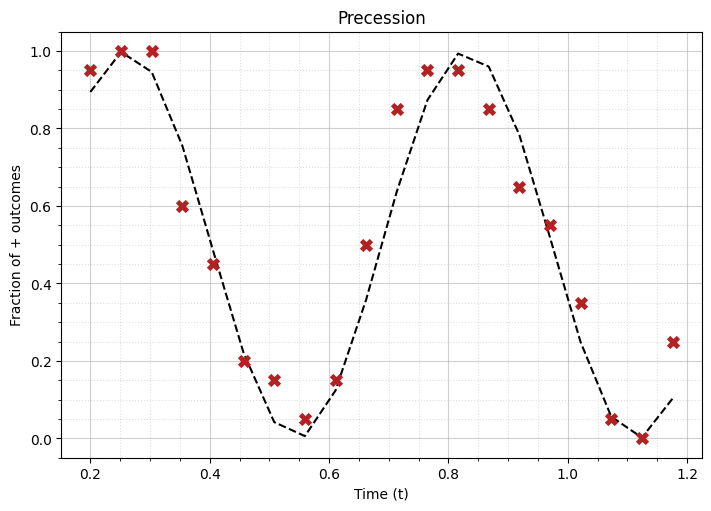

In [18]:
r,b = bayesian_estimate(ts2, Ds2, w_domain = (0,20), B_domain=(0, np.pi))
pred = prob2(ts, r, b)
plot_data(ts, Ds, ref = pred)

In [19]:
print(f"> Curve fit (real data): estimated ω = {r:.1f}, B = {b:.1f}.")

> Curve fit (real data): estimated ω = 11.0, B = 1.7.
